In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Adjust this if your 'Palm Datasets' folder lives elsewhere in your Drive
DRIVE_FOLDER = '/content/drive/MyDrive/Palm Datasets'
import os
print(os.listdir(DRIVE_FOLDER))

Mounted at /content/drive
['cards.zip', 'Hands.zip']


In [ ]:
import zipfile, os

os.makedirs('/content/hands_data', exist_ok=True)
os.makedirs('/content/tarot_data', exist_ok=True)

with zipfile.ZipFile(f'{DRIVE_FOLDER}/Hands.zip', 'r') as z:
    z.extractall('/content/hands_data')

with zipfile.ZipFile(f'{DRIVE_FOLDER}/cards.zip', 'r') as z:
    z.extractall('/content/tarot_data')

print('Extraction done.')

Extraction done.


In [ ]:
import urllib.request
urllib.request.urlretrieve(
    'https://raw.githubusercontent.com/metabismuth/tarot-json/master/tarot.json',
    '/content/tarot_data/tarot.json'
)

('/content/tarot_data/tarot.json', <http.client.HTTPMessage at 0x798ee55e6930>)

In [ ]:
def print_tree(path, max_depth=2, prefix=''):
    if max_depth < 0:
        return
    try:
        entries = sorted(os.listdir(path))
    except NotADirectoryError:
        return
    for i, entry in enumerate(entries[:15]):  # cap listing so it doesn't flood output
        full = os.path.join(path, entry)
        print(prefix + entry + ('/' if os.path.isdir(full) else ''))
        if os.path.isdir(full):
            print_tree(full, max_depth - 1, prefix + '  ')
    if len(entries) > 15:
        print(prefix + f'... and {len(entries) - 15} more')

print('--- hands_data ---')
print_tree('/content/hands_data')
print()
print('--- tarot_data ---')
print_tree('/content/tarot_data')

--- hands_data ---
Hands/
  Hand_0000002.jpg
  Hand_0000003.jpg
  Hand_0000004.jpg
  Hand_0000005.jpg
  Hand_0000006.jpg
  Hand_0000007.jpg
  Hand_0000008.jpg
  Hand_0000009.jpg
  Hand_0000010.jpg
  Hand_0000011.jpg
  Hand_0000012.jpg
  Hand_0000013.jpg
  Hand_0000014.jpg
  Hand_0000015.jpg
  Hand_0000016.jpg
  ... and 11061 more

--- tarot_data ---
c01.jpg
c02.jpg
c03.jpg
c04.jpg
c05.jpg
c06.jpg
c07.jpg
c08.jpg
c09.jpg
c10.jpg
c11.jpg
c12.jpg
c13.jpg
c14.jpg
m00.jpg
... and 64 more


In [ ]:
%cd /content
!git clone https://github.com/yeonsumia/palmistry.git
%cd /content/palmistry/code
!pip install pillow-heif mediapipe scikit-image -q

/content
Cloning into 'palmistry'...
remote: Enumerating objects: 262, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 262 (delta 10), reused 4 (delta 4), pack-reused 238 (from 3)
Receiving objects: 100% (262/262), 308.92 MiB | 22.57 MiB/s, done.
Resolving deltas: 100% (61/61), done.
Updating files: 100% (91/91), done.
/content/palmistry/code
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 9.4 MB/s eta 0:00:00


In [ ]:
!pip uninstall -y mediapipe -q
!pip install mediapipe==0.10.14 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 11.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grain 0.2.18 requires protobuf>=5.28.3, but you have protobuf 4.25.9 which is incompatible.
tensorflow 2.20.0 requires protobuf>=5.28.0, but you have protobuf 4.25.9 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.9 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.9 which is incompatible.


In [ ]:
import os

In [ ]:
import glob, shutil

# ⬇️ EDIT THIS after checking Cell 3's printed tree
HAND_IMAGES_SUBDIR = '/content/hands_data/Hands'  # <-- change if your folder name differs

os.makedirs('/content/palmistry/code/input', exist_ok=True)

all_hand_imgs = glob.glob(f'{HAND_IMAGES_SUBDIR}/*.jpg')
print(f'Found {len(all_hand_imgs)} images')

# copy a small sample first (5 images) to test before running the full batch
sample_imgs = all_hand_imgs[:5]
for img_path in sample_imgs:
    shutil.copy(img_path, '/content/palmistry/code/input/')

print('Copied sample images:', [os.path.basename(p) for p in sample_imgs])

Found 11076 images
Copied sample images: ['Hand_0006713.jpg', 'Hand_0008550.jpg', 'Hand_0005388.jpg', 'Hand_0001373.jpg', 'Hand_0001816.jpg']


In [ ]:
!ls /content/palmistry/code/  # see what's actually there

# if read_palm.py is missing, wipe and re-clone cleanly:
import shutil
shutil.rmtree('/content/palmistry', ignore_errors=True)

%cd /content
!git clone https://github.com/yeonsumia/palmistry.git
%cd /content/palmistry/code
!ls  # confirm read_palm.py is now present

checkpoint	   input	   __pycache__	 rectification.py
classification.py  measurement.py  README.md	 requirements.txt
detection.py	   model.py	   read_palm.py  tools.py
/content
Cloning into 'palmistry'...
remote: Enumerating objects: 262, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 262 (delta 10), reused 4 (delta 4), pack-reused 238 (from 3)
Receiving objects: 100% (262/262), 308.92 MiB | 21.48 MiB/s, done.
Resolving deltas: 100% (61/61), done.
Updating files: 100% (91/91), done.
/content/palmistry/code
checkpoint	   input	   __pycache__	 rectification.py
classification.py  measurement.py  README.md	 requirements.txt
detection.py	   model.py	   read_palm.py  tools.py


In [ ]:
!pip install "protobuf==5.29.1" -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.7/319.7 kB 3.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mediapipe 0.10.14 requires protobuf<5,>=4.25.3, but you have protobuf 5.29.1 which is incompatible.


In [ ]:
path = '/content/palmistry/code/classification.py'

with open(path, 'r') as f:
    content = f.read()

content = content.replace(
    'skel_img = cv2.cvtColor(skeletonize(img), cv2.COLOR_BGR2GRAY)',
    'skel_img = cv2.cvtColor((skeletonize(img) * 255).astype("uint8"), cv2.COLOR_BGR2GRAY)'
)
content = content.replace(
    'skel_img = cv2.cvtColor(skeletonize(palmline_img), cv2.COLOR_BGR2GRAY)',
    'skel_img = cv2.cvtColor((skeletonize(palmline_img) * 255).astype("uint8"), cv2.COLOR_BGR2GRAY)'
)

with open(path, 'w') as f:
    f.write(content)

print('Patched.')

Patched.


In [ ]:
%cd /content/palmistry/code
!python read_palm.py --input hand1.jpg

/content/palmistry/code
2026-07-27 13:33:08.015076: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-27 13:33:09.941861: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1785159195.847331    5954 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1785159195.957652    5954 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: Symb

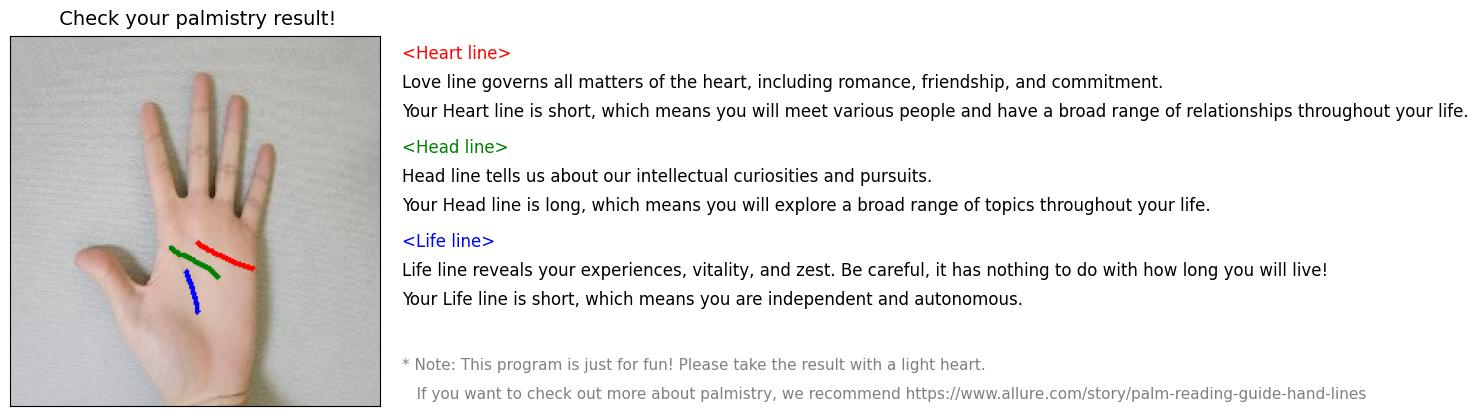

In [ ]:
from IPython.display import Image as IPImage, display
display(IPImage('/content/palmistry/code/results/result.jpg'))

In [ ]:
%cd /content
!git clone https://github.com/yeonsumia/palmistry.git
%cd /content/palmistry/code
!pip install pillow-heif mediapipe==0.10.14 scikit-image -q
!pip install "protobuf==5.29.1" -q

# patch classification.py: skeletonize() now returns bool, cv2.cvtColor needs uint8
path = '/content/palmistry/code/classification.py'
with open(path, 'r') as f:
    content = f.read()
content = content.replace(
    'skel_img = cv2.cvtColor(skeletonize(img), cv2.COLOR_BGR2GRAY)',
    'skel_img = cv2.cvtColor((skeletonize(img) * 255).astype("uint8"), cv2.COLOR_BGR2GRAY)'
)
content = content.replace(
    'skel_img = cv2.cvtColor(skeletonize(palmline_img), cv2.COLOR_BGR2GRAY)',
    'skel_img = cv2.cvtColor((skeletonize(palmline_img) * 255).astype("uint8"), cv2.COLOR_BGR2GRAY)'
)
with open(path, 'w') as f:
    f.write(content)
print('classification.py patched.')
print()
print('>>> IMPORTANT: Runtime -> Restart session now, then continue from Cell 5. <<<')

/content
fatal: destination path 'palmistry' already exists and is not an empty directory.
/content/palmistry/code
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grain 0.2.18 requires protobuf>=5.28.3, but you have protobuf 4.25.9 which is incompatible.
tensorflow 2.20.0 requires protobuf>=5.28.0, but you have protobuf 4.25.9 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.9 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.9 which is incompatible.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mediapipe 0.10.14 requires protobuf<5,>=4.25.3, but you have protobuf 5.29.1 which is incompatible.
classification.py patched.

>>> IMPORTANT

In [ ]:
%cd /content/palmistry/code
!python read_palm.py --input hand1.jpg

/content/palmistry/code
2026-07-27 13:35:42.220072: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-27 13:35:42.333753: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1785159347.989166    6819 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1785159348.027592    6819 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: Symb

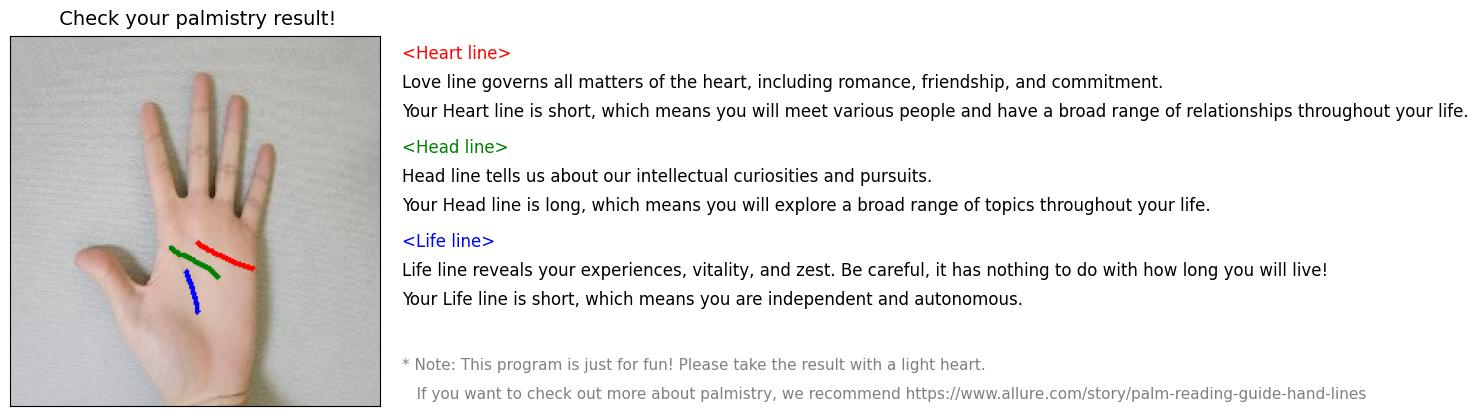

In [ ]:
from IPython.display import Image as IPImage, display
display(IPImage('/content/palmistry/code/results/result.jpg'))

In [ ]:
import glob, shutil

# ⬇️ EDIT THIS after checking Cell 3's printed tree
HAND_IMAGES_SUBDIR = '/content/hands_data/Hands'  # <-- change if your folder name differs

os.makedirs('/content/palmistry/code/input', exist_ok=True)

all_hand_imgs = glob.glob(f'{HAND_IMAGES_SUBDIR}/*.jpg')
print(f'Found {len(all_hand_imgs)} images')

# copy a small sample first (5 images) to test before running the full batch
sample_imgs = all_hand_imgs[:5]
for img_path in sample_imgs:
    shutil.copy(img_path, '/content/palmistry/code/input/')

print('Copied sample images:', [os.path.basename(p) for p in sample_imgs])

Found 11076 images
Copied sample images: ['Hand_0006713.jpg', 'Hand_0008550.jpg', 'Hand_0005388.jpg', 'Hand_0001373.jpg', 'Hand_0001816.jpg']


In [ ]:
%cd /content/palmistry/code
test_image = os.path.basename(sample_imgs[0])
!python read_palm.py --input {test_image}

/content/palmistry/code
2026-07-27 13:36:36.157950: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-27 13:36:36.262661: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1785159402.087187    7070 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1785159402.117881    7071 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: Symb

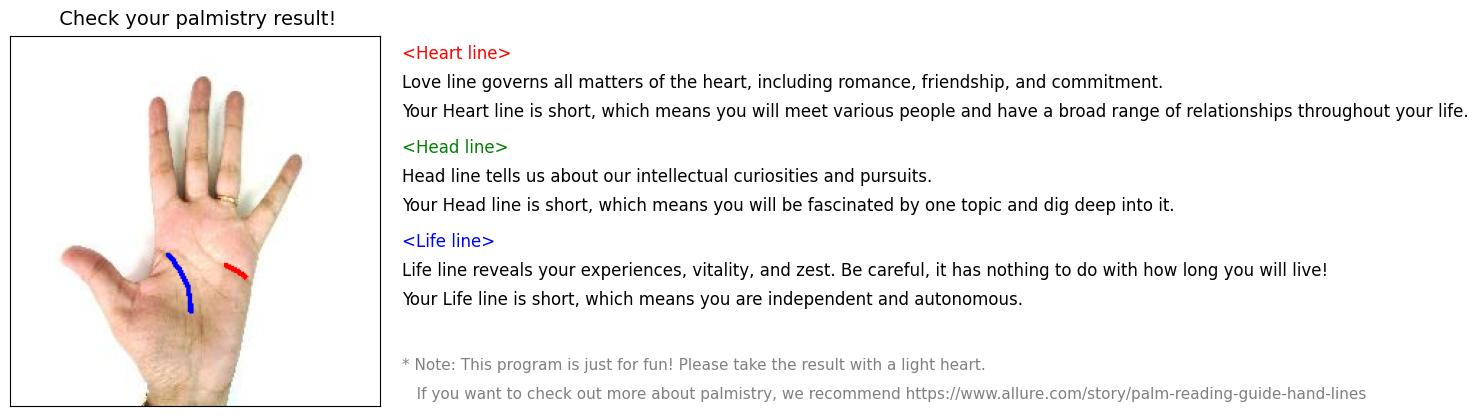

In [ ]:
from IPython.display import Image as IPImage, display
display(IPImage('/content/palmistry/code/results/result.jpg'))

In [ ]:
import json, urllib.request

# only needed if tarot_data/ has no .json file — skip if you already have one
urllib.request.urlretrieve(
    'https://raw.githubusercontent.com/metabismuth/tarot-json/master/tarot.json',
    '/content/tarot_data/tarot.json'
)

# ⬇️ EDIT THIS if your file/path differs
TAROT_JSON_PATH = '/content/tarot_data/tarot.json'

with open(TAROT_JSON_PATH, 'r') as f:
    tarot_data = json.load(f)

# structure varies by which json you loaded (tarot.json is a list, tarot-images.json is often {'cards': [...]})
cards = tarot_data['cards'] if isinstance(tarot_data, dict) and 'cards' in tarot_data else tarot_data
print(f'Loaded {len(cards)} cards')
print(json.dumps(cards[0], indent=2))

Loaded 78 cards
{
  "name": "The Fool",
  "number": "0",
  "arcana": "Major Arcana",
  "suit": null
}


In [ ]:
import random

def draw_spread(cards, n=3):
    drawn = random.sample(cards, n)
    reading = []
    for card in drawn:
        reversed_ = random.choice([True, False])
        name = card.get('name') or card.get('name_short') or card.get('card_name', 'Unknown')
        meaning_key = 'meaning_rev' if reversed_ else 'meaning_up'
        meaning = card.get(meaning_key) or card.get('upright_meaning' if not reversed_ else 'reversed_meaning', 'No meaning found in dataset for this field name — check card keys with print(cards[0].keys())')
        reading.append({'card': name, 'reversed': reversed_, 'meaning': meaning})
    return reading

spread = draw_spread(cards, n=3)
for r in spread:
    orientation = 'Reversed' if r['reversed'] else 'Upright'
    print(f"{r['card']} ({orientation}): {r['meaning']}\n")

Ten of Swords (Upright): No meaning found in dataset for this field name — check card keys with print(cards[0].keys())

Page of Wands (Reversed): No meaning found in dataset for this field name — check card keys with print(cards[0].keys())

Six of Wands (Upright): No meaning found in dataset for this field name — check card keys with print(cards[0].keys())



In [ ]:
print(cards[0].keys())

In [ ]:
import json, urllib.request

# corrected source — this one actually has meanings (previous URL had name/number/arcana only)
urllib.request.urlretrieve(
    'https://raw.githubusercontent.com/samia-mnn/tarot_reader1.0/master/tarot.json',
    '/content/tarot_data/tarot.json'
)

with open('/content/tarot_data/tarot.json', 'r') as f:
    cards = json.load(f)

print(f'Loaded {len(cards)} cards')
print(cards[0].keys())

Loaded 78 cards
dict_keys(['name', 'number', 'arcana', 'suit', 'img', 'fortune_telling', 'keywords', 'meanings', 'Archetype', 'Hebrew Alphabet', 'Numerology', 'Elemental', 'Mythical/Spiritual', 'Questions to Ask'])


In [ ]:
import random

def draw_spread(cards, n=3):
    drawn = random.sample(cards, n)
    reading = []
    for card in drawn:
        reversed_ = random.choice([True, False])
        name = card['name']
        meaning_list = card['meanings']['shadow'] if reversed_ else card['meanings']['light']
        meaning = '; '.join(meaning_list[:3])  # first 3 keywords-style phrases, keeps it readable
        reading.append({'card': name, 'reversed': reversed_, 'meaning': meaning, 'image_file': card.get('img')})
    return reading

spread = draw_spread(cards, n=3)
for r in spread:
    orientation = 'Reversed' if r['reversed'] else 'Upright'
    print(f"{r['card']} ({orientation}): {r['meaning']}\n")

The Chariot (Upright): Breaking through barriers; Moving forward with confidence and authority; Reaching the pinnacle of success

Ace of Swords (Upright): Making objective decisions; Applying logic; Reasoning your way out of a difficult situation

Wheel of Fortune (Upright): Allowing events to unfold; Seeing the larger pattern in everyday events; Trusting your luck



In [ ]:
def generate_combined_report(palm_result_status, tarot_spread):
    report = {
        'palm_reading': palm_result_status,
        'tarot_reading': tarot_spread,
    }
    return report

combined = generate_combined_report(readings, spread)

with open('/content/palmistry/code/results/combined_report.json', 'w') as f:
    json.dump(combined, f, indent=2)

print(json.dumps(combined, indent=2))

{
  "palm_reading": {
    "Hand_0006713.jpg": {
      "status": "ok",
      "result_image": "results/result_Hand_0006713.jpg.jpg"
    }
  },
  "tarot_reading": [
    {
      "card": "The Chariot",
      "reversed": false,
      "meaning": "Breaking through barriers; Moving forward with confidence and authority; Reaching the pinnacle of success",
      "image_file": "m07.jpg"
    },
    {
      "card": "Ace of Swords",
      "reversed": false,
      "meaning": "Making objective decisions; Applying logic; Reasoning your way out of a difficult situation",
      "image_file": "s01.jpg"
    },
    {
      "card": "Wheel of Fortune",
      "reversed": false,
      "meaning": "Allowing events to unfold; Seeing the larger pattern in everyday events; Trusting your luck",
      "image_file": "m10.jpg"
    }
  ]
}
